In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN 

In [2]:
df = pd.read_csv('C:/Users/Saee Beri/OneDrive/Desktop/Msc Datascience/Sem 2/ML Assignments/Mall_Customers.csv')
data= pd.DataFrame(df)
X_train = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [3]:
clustering = DBSCAN(eps=12.5, min_samples=4).fit(X_train)
DBSCAN_dataset = X_train.copy()
DBSCAN_dataset.loc[:,'Cluster'] = clustering.labels_

In [4]:
DBSCAN_dataset.Cluster.value_counts().to_frame()
DBSCAN_dataset

,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,19,15,39,0
1,21,15,81,0
2,20,16,6,-1
3,23,16,77,0
4,31,17,40,0
...,...,...,...,...
195,35,120,79,-1
196,45,126,28,-1
197,32,126,74,-1
198,32,137,18,-1


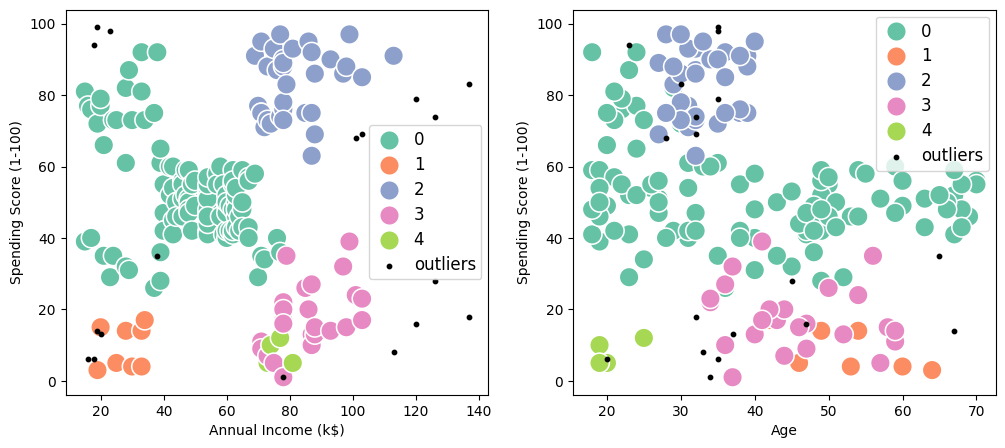

In [5]:
outliers = DBSCAN_dataset[DBSCAN_dataset['Cluster'] == -1]

fig2, axes = plt.subplots(1, 2, figsize=(12, 5))

# Remove special characters from column names or use them with backticks (if supported), or better yet:
DBSCAN_dataset.columns = DBSCAN_dataset.columns.str.strip()  # Strip extra spaces just in case

sns.scatterplot(x='Annual Income (k$)',
                y='Spending Score (1-100)',
                data=DBSCAN_dataset[DBSCAN_dataset['Cluster'] != -1],
                hue='Cluster',
                ax=axes[0],
                palette='Set2',
                legend='full',
                s=200)
sns.scatterplot(x='Age', y='Spending Score (1-100)',

                data=DBSCAN_dataset[DBSCAN_dataset['Cluster']!=-1],

                hue='Cluster', palette='Set2', ax=axes[1], legend='full', s=200)

axes[0].scatter(outliers['Annual Income (k$)'], outliers['Spending Score (1-100)'], s=10, label='outliers', c="k")

axes[1].scatter(outliers['Age'], outliers['Spending Score (1-100)'], s=10, label='outliers', c="k")
axes[0].legend()
axes[1].legend()

plt.setp(axes[0].get_legend().get_texts(), fontsize='12')
plt.setp(axes[1].get_legend().get_texts(), fontsize='12')

plt.show()